# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Install World cloud
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Import Data

Import dataset then convert into dataframe by using pandas. After converted, display dataframe info.

In [4]:
military_aircraft_df = pd.read_csv("/content/military_aircraft_health_dataset - Copy.csv")
military_aircraft_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Aircraft_Type           9996 non-null   object 
 1   Engine_Type             9996 non-null   object 
 2   Total_Flight_Hours      9996 non-null   float64
 3   Engine_RPM              9996 non-null   float64
 4   Oil_Pressure            9996 non-null   float64
 5   Hydraulic_Pressure      9996 non-null   float64
 6   Vibration_Level         9996 non-null   float64
 7   Primary_Voltage         9996 non-null   float64
 8   Secondary_Voltage       9996 non-null   float64
 9   Engine_Temp             9996 non-null   float64
 10  Fuel_Flow_Rate          9996 non-null   float64
 11  Needs_Repair            9996 non-null   int64  
 12  Critical_System         2996 non-null   object 
 13  Engine_Temp_Normalized  9996 non-null   float64
 14  Temp_Deviation          9996 non-null   

In [5]:
military_aircraft_df.head()

,Aircraft_Type,Engine_Type,Total_Flight_Hours,Engine_RPM,Oil_Pressure,Hydraulic_Pressure,Vibration_Level,Primary_Voltage,Secondary_Voltage,Engine_Temp,Fuel_Flow_Rate,Needs_Repair,Critical_System,Engine_Temp_Normalized,Temp_Deviation,Aircraft_ID
0,Su-25,Turboprop,2489.376267,90.502260,2.489052,208.829542,2.198030,165.905810,165.620090,776.566918,1.05,1,"Electrics,Engine",0.941417,29.427820,Su-25_0
1,Su-25,Turboprop,2985.241977,72.891857,2.159059,208.809618,2.681662,194.885806,28.177534,588.713847,1.14,0,NaN,0.471785,-1.881025,Su-25_1
2,Su-25,Turboprop,1167.731902,79.715050,2.506106,205.549701,3.436982,190.348611,27.701686,575.479420,1.12,0,NaN,0.438699,-4.086763,Su-25_2
3,Su-25,Turboprop,3168.875364,71.259336,3.061992,207.087823,2.731308,195.941819,27.231607,535.126313,1.07,0,NaN,0.337816,-10.812281,Su-25_3
4,Su-25,Turboprop,3235.994628,70.012859,3.175902,208.822751,3.552030,193.896082,27.332756,607.732955,1.07,0,NaN,0.519332,1.288826,Su-25_4


# Exploratory Data Analysis (EDA)

In [ ]:
military_aircraft_df.describe()

,Total_Flight_Hours,Engine_RPM,Oil_Pressure,Hydraulic_Pressure,Vibration_Level,Primary_Voltage,Secondary_Voltage,Engine_Temp,Fuel_Flow_Rate,Needs_Repair,Engine_Temp_Normalized,Temp_Deviation
count,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000
mean,2565.989915,79.165720,2.692877,141.753946,3.851989,175.521314,40.655076,528.586184,0.834512,0.299720,0.491618,-0.535565
std,1410.366605,6.556424,0.595838,93.448427,1.334352,60.873844,47.869865,157.168606,0.753504,0.458158,0.154015,9.850946
min,101.255262,70.001514,1.600604,0.000000,2.000110,24.020655,23.001199,150.036703,0.040000,0.000000,0.300039,-13.328516
25%,1359.101035,74.243745,2.271303,55.378411,2.851853,191.611466,25.946591,530.314601,0.180000,0.000000,0.383039,-7.434112
50%,2555.636712,78.314959,2.657975,204.352824,3.657597,198.196651,26.891412,568.012911,1.110000,0.000000,0.466835,-2.136164
75%,3791.295144,82.435019,3.045856,212.379878,4.505655,204.695471,27.877377,604.070650,1.200000,1.000000,0.546399,2.957728
max,4999.128610,99.999358,4.499269,278.085138,7.998821,239.945605,239.985531,799.417939,3.600000,1.000000,0.999630,33.236323


In [ ]:
military_aircraft_df['Needs_Repair'].unique()

array([1, 0])

In [ ]:
military_aircraft_df['Engine_Type'].unique()

array(['Turboprop', 'Turbofan', 'Turboshaft', 'Piston'], dtype=object)

In [6]:
military_aircraft_df.isnull().sum()

,0
Aircraft_Type,0
Engine_Type,0
Total_Flight_Hours,0
Engine_RPM,0
Oil_Pressure,0
Hydraulic_Pressure,0
Vibration_Level,0
Primary_Voltage,0
Secondary_Voltage,0
Engine_Temp,0


# Data Pre-processing

In [14]:
# Copy dataset
military_aircraft_df_copy = military_aircraft_df.copy()

In [17]:
# missing values
military_aircraft_df_copy = military_aircraft_df_copy['Critical_System'].fillna("No Critical")

In [18]:
military_aircraft_df_copy.isnull().sum()

np.int64(0)

In [19]:
military_aircraft_df_copy.head()

,Critical_System
0,"Electrics,Engine"
1,No Critical
2,No Critical
3,No Critical
4,No Critical


In [22]:
# Check duplicate
military_aircraft_df_copy.duplicated().sum()

np.int64(9756)

In [23]:
# Drop duplicate
military_aircraft_df_copy.drop_duplicates(inplace=True)

In [24]:
# Check dplicated again
military_aircraft_df_copy.duplicated().sum()

np.int64(0)

# World Cloud Map

Set the stopwords and save it into variable stopwords.

In [ ]:
# set Stopwords
stopwords = set(STOPWORDS)

Convert all of the dataframe Critical System values into set of texts.

In [ ]:
# Convert column values into words
critical_system_text = ' '.join(military_aircraft_df['Critical_System'].dropna().astype(str))

Initialize word cloud instance. Generate wordcloud with critical_system_text as input parameter. Save word cloud into critical_systems_cloud.

In [ ]:
# Word cloud instance initialization
wordcloud = WordCloud(
    background_color='white',
    stopwords=stopwords,
    max_words=200,
    max_font_size=40,
    scale=3,
    random_state=1
    )

# Set word cloud into crtical system
critical_systems_cloud = wordcloud.generate(critical_system_text)

Show word cloud visualization.

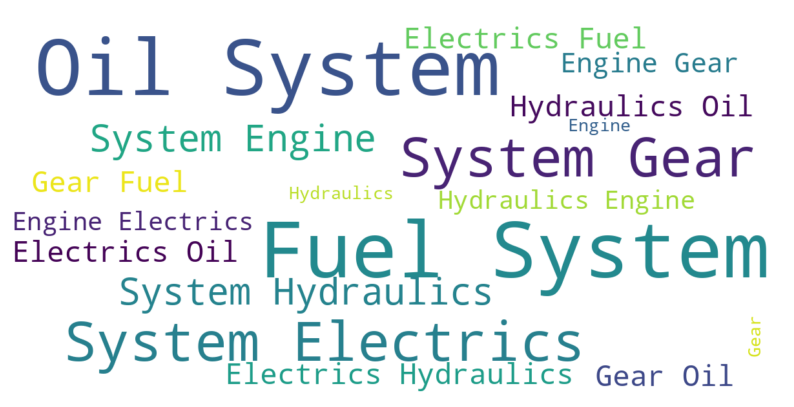

In [ ]:
# Visualize World Cloud
plt.figure(figsize=(10, 10))
plt.imshow(critical_systems_cloud,interpolation='bilinear')
plt.axis('off')
plt.show()

If you want to convert it into tables, do the instruction

In [ ]:
Critical_Systems_Count = military_aircraft_df['Critical_System'].value_counts().reset_index()
Critical_Systems_Count.columns = ['Critical_System', 'Count']
Critical_Systems_Count.head(10)

,Critical_System,Count
0,Oil System,169
1,Gear,165
2,Electrics,161
3,Fuel System,151
4,Hydraulics,150
5,Engine,148
6,"Fuel System,Electrics",61
7,"Hydraulics,Gear",58
8,"Electrics,Hydraulics",52
9,"Hydraulics,Fuel System",52


# Data Visualization